In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

Давайте подивимося, як LSTM можна використовувати для побудови нейронної мережі прогнозування часових.

Будемо працювати з задачею прогнозування кількості пасажирів міжнародних авіаліній. З цим набором даних ми вже працювали в лекції "Time Series Analysis" і ви зможете порівняти результати :)

Задача полягає в тому, щоб за заданими роком і місяцем передбачити кількість пасажирів міжнародних авіаліній в одиницях виміру 1,000. Дані охоплюють період з січня 1949 року по грудень 1960 року, тобто 12 років, зі 144 спостереженнями.

Це регресійна задача. Тобто, знаючи кількість пасажирів (в тисячах) за останні місяці, можна передбачити, якою буде кількість пасажирів у наступному місяці. Набір даних має лише одну характеристику: "Кількість пасажирів" - `Passengers`.

Далі вже наведений код для читання даних, але нам їх ще треба буде трошки обробити.

In [2]:
# Завантаження даних
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df.set_index('Month', inplace=True)
display(df.head())

,Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


**Завдання 1.** Створіть змінну типу `numpy.ndarray`, яка містить значення кількості пасажирів в форматі `float32`. Такий формат даних нам треба для тренування нейромережі.

In [3]:
data = df['Passengers'].values.astype(np.float32)

print(type(data))
print(data.dtype)
print(data[:5])

<class 'numpy.ndarray'>
float32
[112. 118. 132. 129. 121.]


Очікуваний результат:
```array([112., 118., 132., 129., 121.], dtype=float32)```

**Завдання 2**. Розбийте дані на тренувальні і валідаційні у співвідношенні 67% йде у тренування, 33 - у валідацію. Памʼятаємо, що ми працюємо з tim series, відповідно, навчаємось на давніших, валідуємось - на новіших.

In [4]:
train_size = int(len(data) * 0.67)
train, test = data[:train_size], data[train_size:]

len(train), len(test)

(96, 48)

**Завдання 3**.

Реалізуйте функцію `create_dataset`, яка перетворить одномірний часовий ряд (набір даних) у формат, придатний для тренування нейромережі.

Функція повинна приймати два аргументи:
- `dataset` — numpy-масив часового ряду,
- `lookback` — кількість попередніх кроків, які використовуватимуться для передбачення.

Функція повинна повернути два **тензори** PyTorch:
- `X` — набір ознак (вікно попередніх значень),
- `y` — цільові значення (наступні після вікна кроки).

Дані ми будемо подавати моделі в наступному форматі:
`
tensor([[112.],
        [118.],
        [132.],
        [129.],
        [121.]])
`
Відповідно першою розмірністю буде йти розмір вхідного батча, а другою - розмір вхіднизх даних і в нас це 1, бо лише одне значення на вході щоразу.

Після виконання завдання запустіть код нижче. Ми будемо передбачати на основі кількості пасажирів в попередній день кількість пасажирів в наступний, тому `lookback == 1`.

In [5]:
def create_dataset(dataset, lookback):
    X, y = [], []
    for i in range(len(dataset) - lookback):
        X.append(dataset[i:i + lookback])
        y.append(dataset[i + lookback])
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    X = torch.from_numpy(X)
    y = torch.from_numpy(y)
    return X, y

In [6]:
lookback = 1
X_train, y_train = create_dataset(train, lookback=lookback)
X_test, y_test = create_dataset(test, lookback=lookback)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([95, 1]) torch.Size([95])
torch.Size([47, 1]) torch.Size([47])


Очікуваний результат:
```
torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])
```

**Завдання 4**.

Зверніть увагу на розмірності в попередньому завданні. Ми
З допомогою модуля `torch.nn` опишіть клас `AirModel`, який є нейронною мережею для прогнозування кількості пасажирів за допомогою LSTM.

1. **Конструктор класу** повинен приймати параметри `hidden_size`, `num_layers` та ініціювати шари:
   - LSTM-шар з наступними параметрами:
     - `input_size` — кожна точка часового ряду є окремим входом,,
     - `hidden_size` — заданий в конструкторі класу мережі,
     - `num_layers=1` — кількість шарів LSTM, задана в конструкторі мережі,
     - `batch_first=True` — визначає, що першим виміром є розмір батчу.
   - Лінійний шар (`nn.Linear`) для перетворення виходу LSTM на прогноз однієї точки.

2. **Метод forward** повинен виконувати наступні дії:
   - Передати вхідний тензор через LSTM-шар і отримати виходи (ігноруючи приховані стани).
   - Пропустити вихід LSTM через лінійний шар для отримання остаточного прогнозу.

Створіть об'єкт класу `AirModel` зі значеннями параметрів `hidden_size=50`, `num_layers=1` і протестуйте роботу моделі на вхідному тензорі `tensor([[112.]])`. На цьому етапі ми маємо переконатись, що модель здатна генерувати передбачення з рандомно ініційованими вагами.

In [7]:
class AirModel(nn.Module):
    def __init__(self, hidden_size, num_layers):
        super(AirModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(-1)
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out


model = AirModel(hidden_size=50, num_layers=1)

x_sample = torch.tensor([[112.]], dtype=torch.float32)
y_pred = model(x_sample)
print(y_pred.shape)
print(y_pred)

torch.Size([1, 1])
tensor([[-0.3201]], grad_fn=<AddmmBackward0>)


**Завдання 5**.

Створіть об'єкт DataLoader для завантаження даних, використовуючи тренувальні вибірки `X_train` та `y_train`. Ваш DataLoader повинен виконувати наступні вимоги:

1. Використовувати клас `TensorDataset`, щоб об'єднати тензори ознак `X_train` і цільових значень `y_train`.
2. Дані повинні завантажуватися невеликими батчами розміром 8 за допомогою параметра `batch_size`.
3. Використовувати параметр `shuffle=True`, щоб дані перемішувалися перед кожною епохою тренування.


In [8]:
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

for xb, yb in train_loader:
    print(xb.shape, yb.shape)
    break

torch.Size([8, 1]) torch.Size([8])


**Завдання 6**.

1. Реалізуйте навчання нейронної мережі `AirModel` для прогнозування часових рядів, використовуючи Adam-оптимізатор та функцію втрат MSE (середньоквадратичну похибку).
2. Створіть цикл тренування для 2000 епох, у якому на кожній епосі:
   - Виконуйте крок тренування моделі (прямий прохід, обчислення похибки, зворотний прохід і оновлення ваг).
   - Підраховуйте середню похибку на кожному батчі даних і зберігайте її у списку `losses`.
3. Раз на 100 епох проводьте валідацію моделі:
   - Перевіряйте модель на тренувальних та тестових даних без оновлення ваг.
   - Обчислюйте корінь середньоквадратичної похибки (RMSE) для тренувальної та тестової вибірок і виводьте результати на екран.
   
**Примітка:**
- Використовуйте вже створений `DataLoader` для отримання батчів даних.
- Валідацію виконуйте в режимі `eval()`, вимикаючи обчислення градієнтів з `torch.no_grad()`.

**Приклад виходу:**
```
Epoch 0: train RMSE 12.3456, test RMSE 15.6789
Epoch 100: train RMSE 9.8765, test RMSE 12.3456
...
```

In [9]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters())

num_epochs = 2000
losses = []

for epoch in range(num_epochs):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        yb = yb.view(-1, 1)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    epoch_loss = sum(batch_losses) / len(batch_losses)
    losses.append(epoch_loss)

    if epoch % 100 == 0:
        model.eval()
        with torch.no_grad():
            train_preds = model(X_train)
            test_preds = model(X_test)

            train_rmse = torch.sqrt(
                criterion(train_preds, y_train.view(-1, 1))
            ).item()
            test_rmse = torch.sqrt(
                criterion(test_preds, y_test.view(-1, 1))
            ).item()

        print(f"Epoch {epoch}: train RMSE {train_rmse:.4f}, test RMSE {test_rmse:.4f}")


Epoch 0: train RMSE 226.1289, test RMSE 422.5450
Epoch 100: train RMSE 188.9129, test RMSE 383.6333
Epoch 200: train RMSE 158.2224, test RMSE 350.7077
Epoch 300: train RMSE 130.9825, test RMSE 320.2010
Epoch 400: train RMSE 107.6984, test RMSE 292.0198
Epoch 500: train RMSE 89.1332, test RMSE 266.4943
Epoch 600: train RMSE 73.1276, test RMSE 242.0947
Epoch 700: train RMSE 59.2402, test RMSE 219.2370
Epoch 800: train RMSE 48.8004, test RMSE 198.4862
Epoch 900: train RMSE 40.9459, test RMSE 180.0011
Epoch 1000: train RMSE 34.9109, test RMSE 163.7556
Epoch 1100: train RMSE 30.8815, test RMSE 149.8470
Epoch 1200: train RMSE 28.2764, test RMSE 138.7209
Epoch 1300: train RMSE 26.7140, test RMSE 129.3867
Epoch 1400: train RMSE 25.4752, test RMSE 122.1362
Epoch 1500: train RMSE 27.0295, test RMSE 115.7190
Epoch 1600: train RMSE 26.0410, test RMSE 111.0566
Epoch 1700: train RMSE 25.7875, test RMSE 108.8885
Epoch 1800: train RMSE 24.9228, test RMSE 105.3386
Epoch 1900: train RMSE 23.7055, test R

**Завдання 7.** Побудуйте графік лосів. Зробіть висновок з графіку, чи навчилась модель?

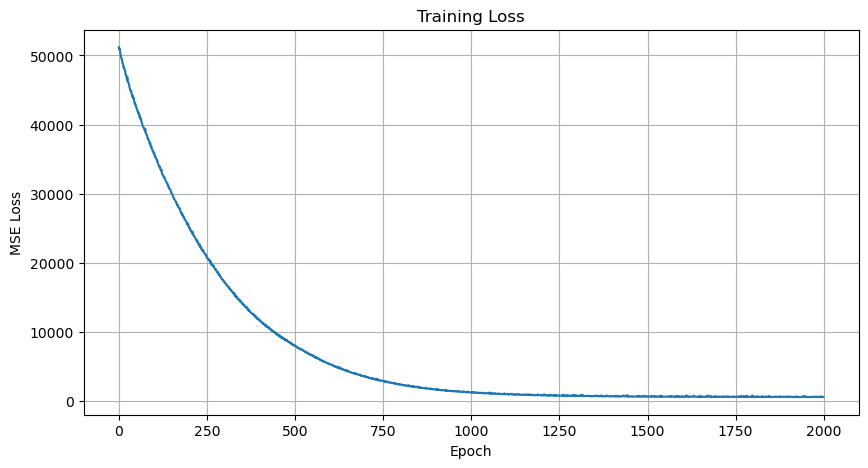

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

### Summary

The training loss consistently decreases over the entire training process, indicating that the model is successfully learning from the data. The RMSE values on both the training and testing sets also steadily improve:

| Epoch | Train RMSE | Test RMSE |
|------:|------------:|-----------:|
| 0 | 226.13 | 422.55 |
| 500 | 89.13 | 266.49 |
| 1000 | 34.91 | 163.76 |
| 1500 | 27.03 | 115.72 |
| 1900 | **23.71** | **102.63** |

Since the values represent thousands of passengers, a test RMSE of ~100 corresponds to an average prediction error of approximately 100,000 passengers. Although still substantial, this is a significant improvement compared to the early stages of training.



Модель навчилась, але не факт, що точно)

Доволі неочікувано, що середньоквадратичне відхилення тестового набору даних буде на порядок більшим за одиниці в нашому наборі даних. Середньоквадратичне відхилення 100 означає, що прогноз і фактичне значення будуть відрізнятися в середньому на 100 (тобто, 100 000 пасажирів у цьому наборі даних).



Щоб краще зрозуміти якість прогнозу, ви можете побудувати графік з кодом нижче (а ще нижче - описано, що відбувається в цьому коді, бо це теж корисно зрозуміти):

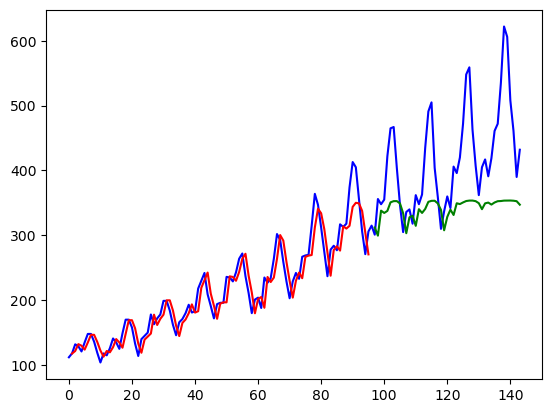

In [11]:
def plot_predicts(m):
    timeseries = data
    with torch.no_grad():
        # Зсув прогнозів для тренувальних даних
        train_plot = np.ones_like(timeseries) * np.nan
        y_pred = m(X_train)
        y_pred = y_pred[:, -1]
        train_plot[lookback:train_size] = m(X_train)[:, -1]

        # Зсув прогнозів для тестових даних
        test_plot = np.ones_like(timeseries) * np.nan
        test_plot[train_size + lookback:len(timeseries)] = m(X_test)[:, -1]

        # Візуалізація результатів
    plt.plot(timeseries, c='b')  # Реальні дані
    plt.plot(train_plot, c='r')  # Прогнози на тренувальних даних
    plt.plot(test_plot, c='g')  # Прогнози на тестових даних
    plt.show()

plot_predicts(model)

### Summary

The prediction visualization confirms that the model:
- effectively captures the **overall upward trend** of the time series,
- partially reflects the **seasonal fluctuations**,
- provides smoother estimates for future months, resulting in less pronounced peaks compared to the real data.

**Conclusion:**
The model has successfully learned meaningful temporal patterns, including both the rising trend and some seasonal structure, though there remains room for further enhancement in capturing the full seasonal amplitude and reducing forecast error.

**Що відбувається в коді вище.** В цьому коді здійснюється процес прогнозування часових рядів за допомогою LSTM моделі, а також виведення графіку, який показує реальні значення, тренувальні та тестові прогнози. Ось що відбувається на кожному етапі:

1. **`torch.no_grad()`**: Цей контекстний менеджер вимикає обчислення градієнтів, що означає, що під час прогнозування не будуть зберігатися проміжні обчислення для зворотного проходу (backpropagation). Це підвищує ефективність під час прогнозування і зменшує використання пам'яті.

2. **Зсув прогнозів для тренувальних даних:**
   - Створюється масив `train_plot`, який має такий самий розмір, як і часовий ряд (`timeseries`), і заповнюється значеннями NaN (`np.nan`), щоб залишити місце для реальних значень.
   - Модель передбачає виходи для тренувальних даних `X_train`.
   - Використовується лише останнє передбачене значення для кожного входу LSTM (`y_pred[:, -1]`).
   - Прогнози зсуваються, починаючи з індексу `lookback` до кінця тренувальних даних (індекс `train_size`). Цей зсув потрібен, щоб зробити прогноз на основі попередніх даних і відобразити його на правильній частині графіку.

3. **Зсув прогнозів для тестових даних:**
   - Створюється масив `test_plot`, який також заповнюється NaN.
   - Прогнози для тестових даних додаються з індексу `train_size + lookback` до кінця реальних даних, щоб відобразити, де модель починає прогнозувати тестову вибірку.

4. **Побудова графіка:**
   - `plt.plot(timeseries, c='b')`: Виводить реальні значення часового ряду (синя лінія).
   - `plt.plot(train_plot, c='r')`: Виводить тренувальні прогнози (червона лінія).
   - `plt.plot(test_plot, c='g')`: Виводить тестові прогнози (зелена лінія).

**Чому це робиться:**
- Зсув прогнозів для тренувальних і тестових даних дозволяє візуально зрівняти, наскільки добре модель прогнозує як на тренувальній, так і на тестовій вибірках. Зазвичай, червона лінія (тренувальні прогнози) повинна точно відповідати синій лінії (реальні дані), а зелена лінія (тестові прогнози) дає змогу побачити, наскільки модель добре працює на нових даних, яких вона раніше не бачила.

**Завдання 8**. Навчіть модель з hidden_size=100 та порівняйте результати прогнозів з попередніми.

In [12]:
model_100 = AirModel(hidden_size=100, num_layers=1)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_100.parameters())

num_epochs = 2000
losses_100 = []

for epoch in range(num_epochs):
    model_100.train()
    batch_losses = []
    for xb, yb in train_loader:
        yb = yb.view(-1, 1)

        optimizer.zero_grad()
        preds = model_100(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    epoch_loss = sum(batch_losses) / len(batch_losses)
    losses_100.append(epoch_loss)

    if epoch % 100 == 0:
        model_100.eval()
        with torch.no_grad():
            train_preds = model_100(X_train)
            test_preds = model_100(X_test)

            train_rmse = torch.sqrt(
                criterion(train_preds, y_train.view(-1, 1))
            ).item()
            test_rmse = torch.sqrt(
                criterion(test_preds, y_test.view(-1, 1))
            ).item()

        print(f"Epoch {epoch}: train RMSE {train_rmse:.4f}, test RMSE {test_rmse:.4f}")


Epoch 0: train RMSE 225.5817, test RMSE 421.9538
Epoch 100: train RMSE 147.8587, test RMSE 339.2946
Epoch 200: train RMSE 99.3653, test RMSE 280.9589
Epoch 300: train RMSE 70.0559, test RMSE 237.1628
Epoch 400: train RMSE 49.9135, test RMSE 200.4792
Epoch 500: train RMSE 37.7648, test RMSE 171.3286
Epoch 600: train RMSE 30.9399, test RMSE 148.3354
Epoch 700: train RMSE 27.1084, test RMSE 131.1055
Epoch 800: train RMSE 25.3460, test RMSE 118.6990
Epoch 900: train RMSE 24.6753, test RMSE 110.7808
Epoch 1000: train RMSE 25.2925, test RMSE 101.7251
Epoch 1100: train RMSE 23.6191, test RMSE 99.2047
Epoch 1200: train RMSE 23.3198, test RMSE 95.7363
Epoch 1300: train RMSE 23.9270, test RMSE 93.6596
Epoch 1400: train RMSE 23.1794, test RMSE 92.2010
Epoch 1500: train RMSE 24.1522, test RMSE 88.6668
Epoch 1600: train RMSE 24.3575, test RMSE 90.1783
Epoch 1700: train RMSE 23.8681, test RMSE 86.4804
Epoch 1800: train RMSE 24.0325, test RMSE 85.6078
Epoch 1900: train RMSE 23.2280, test RMSE 86.2472

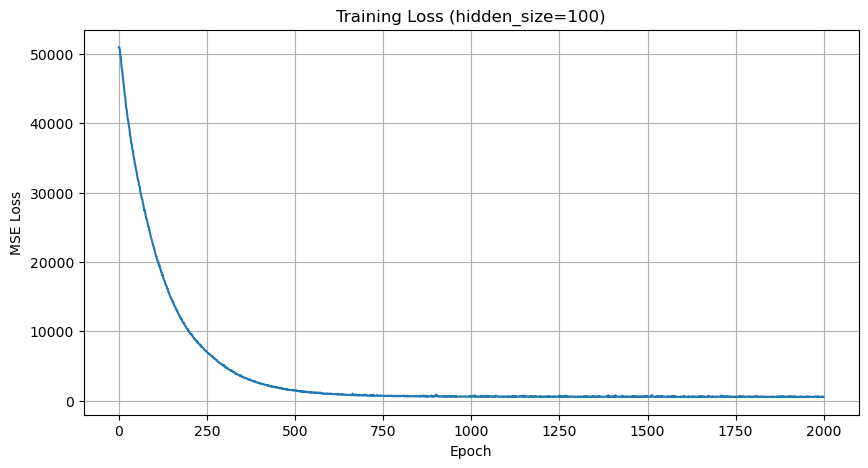

In [13]:
plt.figure(figsize=(10,5))
plt.plot(losses_100)
plt.title("Training Loss (hidden_size=100)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

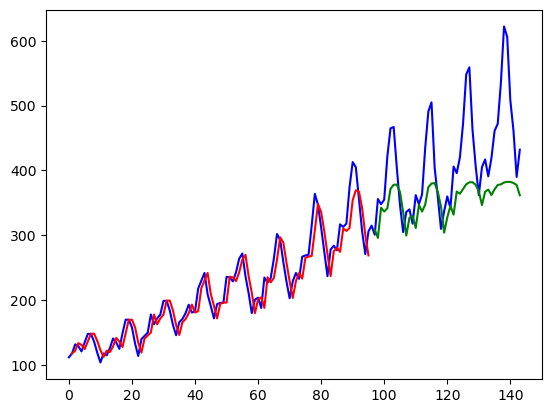

In [14]:
plot_predicts(model_100)

In [15]:
def run_experiment(lookback, hidden_size=100, num_epochs=2000, lr=0.01, batch_size=8):
    train_size = int(len(data) * 0.67)
    train, test = data[:train_size], data[train_size:]

    X_train, y_train = create_dataset(train, lookback)
    X_test, y_test = create_dataset(test, lookback)

    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    model = AirModel(hidden_size=hidden_size, num_layers=1)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters())

    losses = []

    for epoch in range(num_epochs):
        model.train()
        batch_losses = []
        for xb, yb in train_loader:
            yb = yb.view(-1, 1)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        epoch_loss = sum(batch_losses) / len(batch_losses)
        losses.append(epoch_loss)

        if epoch % 100 == 0:
            model.eval()
            with torch.no_grad():
                train_preds = model(X_train)
                test_preds = model(X_test)
                train_rmse = torch.sqrt(criterion(train_preds, y_train.view(-1, 1))).item()
                test_rmse = torch.sqrt(criterion(test_preds, y_test.view(-1, 1))).item()
            print(f"Epoch {epoch}: lookback {lookback}, train RMSE {train_rmse:.4f}, test RMSE {test_rmse:.4f}")

    return model, losses, X_train, y_train, X_test, y_test, train_size

In [16]:
def plot_predicts_model(model, lookback, X_train, X_test, train_size):
    with torch.no_grad():
        timeseries = data

        train_plot = np.ones_like(timeseries) * np.nan
        train_preds = model(X_train).numpy().flatten()
        train_plot[lookback:train_size] = train_preds

        test_plot = np.ones_like(timeseries) * np.nan
        test_preds = model(X_test).numpy().flatten()
        test_plot[train_size+lookback:len(timeseries)] = test_preds

    plt.figure(figsize=(12, 5))
    plt.plot(timeseries, c='b', label="Real")
    plt.plot(train_plot, c='r', label="Train Predict")
    plt.plot(test_plot, c='g', label="Test Predict")
    plt.legend()
    plt.title(f"AirPassengers Predictions (lookback={lookback})")
    plt.show()


Running lookback=1, hidden_size=50
Epoch 0: lookback 1, train RMSE 226.0321, test RMSE 422.4432
Epoch 100: lookback 1, train RMSE 185.7552, test RMSE 380.2899
Epoch 200: lookback 1, train RMSE 153.8517, test RMSE 345.9185
Epoch 300: lookback 1, train RMSE 125.3666, test RMSE 313.6515
Epoch 400: lookback 1, train RMSE 101.7104, test RMSE 284.1512
Epoch 500: lookback 1, train RMSE 83.2015, test RMSE 257.8466
Epoch 600: lookback 1, train RMSE 66.7995, test RMSE 232.6443
Epoch 700: lookback 1, train RMSE 54.0621, test RMSE 209.5675
Epoch 800: lookback 1, train RMSE 45.0681, test RMSE 188.8943
Epoch 900: lookback 1, train RMSE 38.1263, test RMSE 170.6112
Epoch 1000: lookback 1, train RMSE 32.3534, test RMSE 154.8546
Epoch 1100: lookback 1, train RMSE 32.9794, test RMSE 141.2276
Epoch 1200: lookback 1, train RMSE 27.1149, test RMSE 131.2057
Epoch 1300: lookback 1, train RMSE 25.6837, test RMSE 122.8999
Epoch 1400: lookback 1, train RMSE 24.9950, test RMSE 116.6581
Epoch 1500: lookback 1, tra

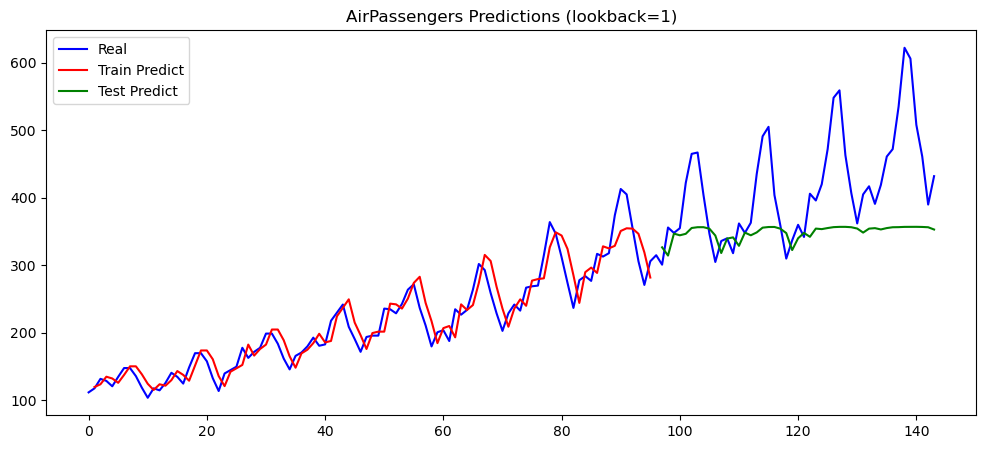

Running lookback=1, hidden_size=100
Epoch 0: lookback 1, train RMSE 225.5110, test RMSE 421.8924
Epoch 100: lookback 1, train RMSE 144.5379, test RMSE 335.5936
Epoch 200: lookback 1, train RMSE 95.9206, test RMSE 276.1254
Epoch 300: lookback 1, train RMSE 66.3742, test RMSE 231.5161
Epoch 400: lookback 1, train RMSE 47.3224, test RMSE 194.9314
Epoch 500: lookback 1, train RMSE 36.4163, test RMSE 166.1889
Epoch 600: lookback 1, train RMSE 31.0776, test RMSE 143.8989
Epoch 700: lookback 1, train RMSE 26.3847, test RMSE 127.7891
Epoch 800: lookback 1, train RMSE 25.1349, test RMSE 115.7600
Epoch 900: lookback 1, train RMSE 24.0308, test RMSE 107.6144
Epoch 1000: lookback 1, train RMSE 27.4010, test RMSE 101.8400
Epoch 1100: lookback 1, train RMSE 25.4460, test RMSE 100.1141
Epoch 1200: lookback 1, train RMSE 23.9156, test RMSE 95.7248
Epoch 1300: lookback 1, train RMSE 25.3797, test RMSE 92.7831
Epoch 1400: lookback 1, train RMSE 23.1129, test RMSE 91.5248
Epoch 1500: lookback 1, train RM

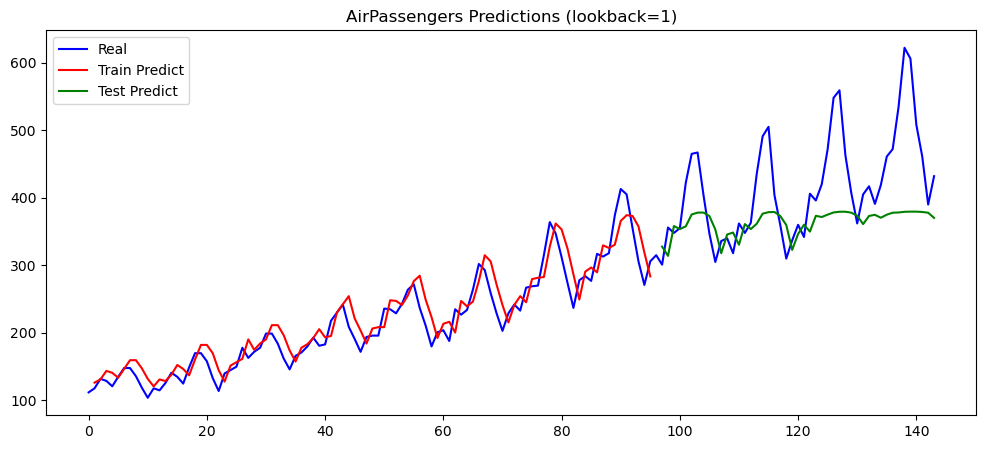

Running lookback=3, hidden_size=50
Epoch 0: lookback 3, train RMSE 227.7017, test RMSE 426.0903
Epoch 100: lookback 3, train RMSE 177.4501, test RMSE 373.3990
Epoch 200: lookback 3, train RMSE 139.9909, test RMSE 332.4704
Epoch 300: lookback 3, train RMSE 109.4000, test RMSE 296.2623
Epoch 400: lookback 3, train RMSE 83.5446, test RMSE 261.3556
Epoch 500: lookback 3, train RMSE 58.8018, test RMSE 222.2478
Epoch 600: lookback 3, train RMSE 44.7888, test RMSE 194.0676
Epoch 700: lookback 3, train RMSE 35.6658, test RMSE 170.7540
Epoch 800: lookback 3, train RMSE 30.2974, test RMSE 152.5826
Epoch 900: lookback 3, train RMSE 27.1449, test RMSE 136.4436
Epoch 1000: lookback 3, train RMSE 25.2905, test RMSE 124.3364
Epoch 1100: lookback 3, train RMSE 24.1625, test RMSE 115.2481
Epoch 1200: lookback 3, train RMSE 23.9504, test RMSE 114.6166
Epoch 1300: lookback 3, train RMSE 23.0866, test RMSE 107.1831
Epoch 1400: lookback 3, train RMSE 22.2384, test RMSE 102.4010
Epoch 1500: lookback 3, trai

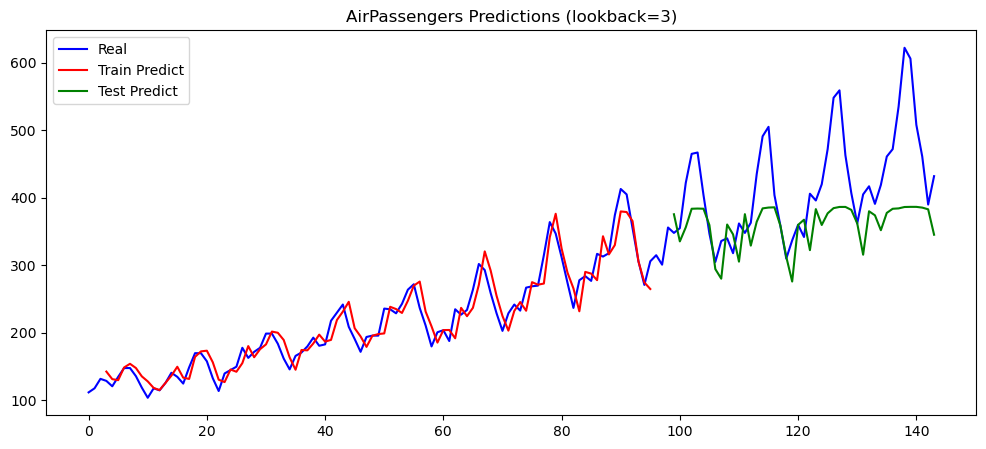

Running lookback=3, hidden_size=100
Epoch 0: lookback 3, train RMSE 227.1304, test RMSE 425.5594
Epoch 100: lookback 3, train RMSE 133.5348, test RMSE 325.1344
Epoch 200: lookback 3, train RMSE 81.1445, test RMSE 257.7512
Epoch 300: lookback 3, train RMSE 49.0180, test RMSE 203.4855
Epoch 400: lookback 3, train RMSE 35.0396, test RMSE 168.8714
Epoch 500: lookback 3, train RMSE 28.5756, test RMSE 144.0075
Epoch 600: lookback 3, train RMSE 25.3917, test RMSE 125.7009
Epoch 700: lookback 3, train RMSE 23.8708, test RMSE 112.0826
Epoch 800: lookback 3, train RMSE 22.6629, test RMSE 103.3587
Epoch 900: lookback 3, train RMSE 21.8954, test RMSE 95.9559
Epoch 1000: lookback 3, train RMSE 21.2078, test RMSE 91.0753
Epoch 1100: lookback 3, train RMSE 20.9243, test RMSE 90.5102
Epoch 1200: lookback 3, train RMSE 20.4363, test RMSE 85.8385
Epoch 1300: lookback 3, train RMSE 20.1783, test RMSE 84.4664
Epoch 1400: lookback 3, train RMSE 20.1399, test RMSE 85.2198
Epoch 1500: lookback 3, train RMSE 

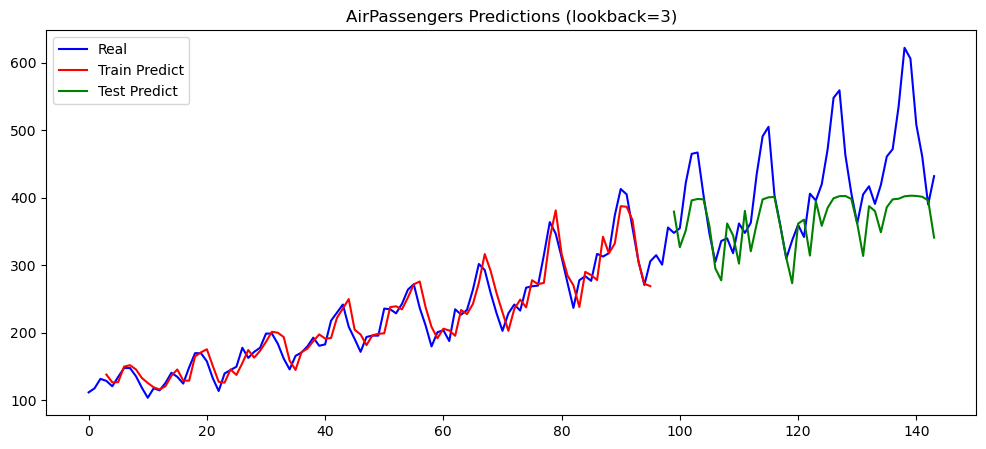

Running lookback=12, hidden_size=50
Epoch 0: lookback 12, train RMSE 235.7567, test RMSE 435.2730
Epoch 100: lookback 12, train RMSE 192.0289, test RMSE 390.0341
Epoch 200: lookback 12, train RMSE 156.1878, test RMSE 351.8968
Epoch 300: lookback 12, train RMSE 125.8537, test RMSE 318.1927
Epoch 400: lookback 12, train RMSE 100.8150, test RMSE 287.8588
Epoch 500: lookback 12, train RMSE 77.2545, test RMSE 255.9196
Epoch 600: lookback 12, train RMSE 57.9090, test RMSE 225.0647
Epoch 700: lookback 12, train RMSE 45.0949, test RMSE 199.5079
Epoch 800: lookback 12, train RMSE 36.4106, test RMSE 179.1723
Epoch 900: lookback 12, train RMSE 29.9929, test RMSE 161.2112
Epoch 1000: lookback 12, train RMSE 23.6443, test RMSE 151.8882
Epoch 1100: lookback 12, train RMSE 20.4711, test RMSE 144.2681
Epoch 1200: lookback 12, train RMSE 18.1163, test RMSE 135.8006
Epoch 1300: lookback 12, train RMSE 16.0287, test RMSE 125.4758
Epoch 1400: lookback 12, train RMSE 13.7734, test RMSE 111.4510
Epoch 1500:

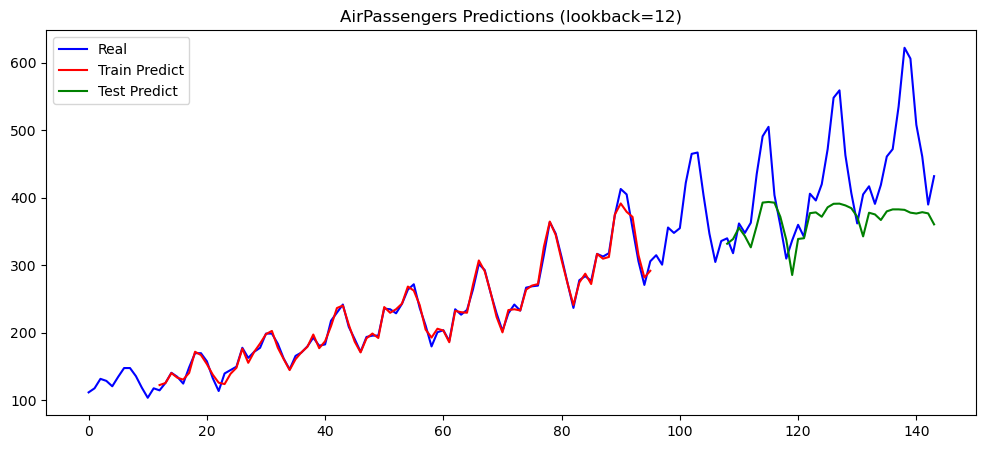

Running lookback=12, hidden_size=100
Epoch 0: lookback 12, train RMSE 235.7241, test RMSE 435.2620
Epoch 100: lookback 12, train RMSE 144.6631, test RMSE 339.3216
Epoch 200: lookback 12, train RMSE 91.4752, test RMSE 275.1875
Epoch 300: lookback 12, train RMSE 56.5729, test RMSE 222.2020
Epoch 400: lookback 12, train RMSE 39.1206, test RMSE 186.6830
Epoch 500: lookback 12, train RMSE 29.4438, test RMSE 161.3033
Epoch 600: lookback 12, train RMSE 22.8614, test RMSE 142.6653
Epoch 700: lookback 12, train RMSE 17.3764, test RMSE 125.8538
Epoch 800: lookback 12, train RMSE 13.9984, test RMSE 114.8891
Epoch 900: lookback 12, train RMSE 11.3754, test RMSE 105.7080
Epoch 1000: lookback 12, train RMSE 9.0152, test RMSE 98.7738
Epoch 1100: lookback 12, train RMSE 7.4430, test RMSE 93.6365
Epoch 1200: lookback 12, train RMSE 6.0018, test RMSE 90.5889
Epoch 1300: lookback 12, train RMSE 5.2938, test RMSE 88.3633
Epoch 1400: lookback 12, train RMSE 4.9292, test RMSE 85.9692
Epoch 1500: lookback 12

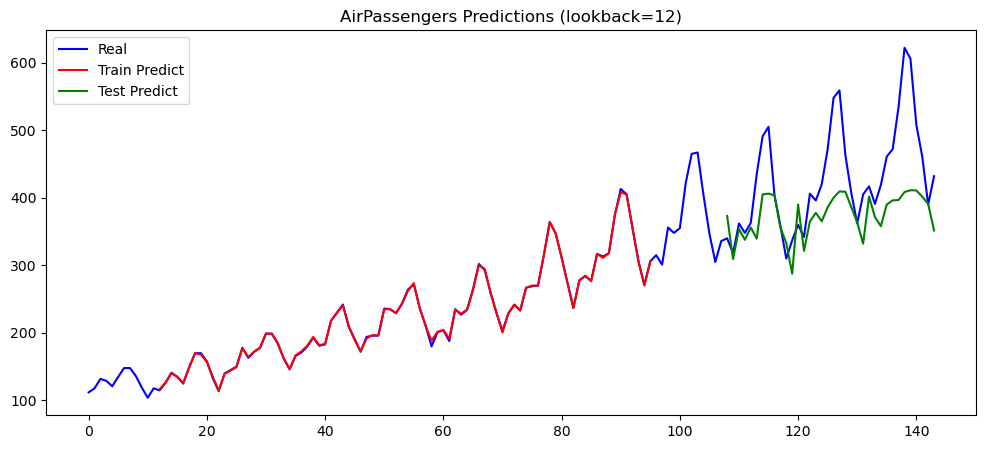

Running lookback=24, hidden_size=50
Epoch 0: lookback 24, train RMSE 248.1343, test RMSE 458.0711
Epoch 100: lookback 24, train RMSE 210.7960, test RMSE 419.8634
Epoch 200: lookback 24, train RMSE 179.0166, test RMSE 386.9099
Epoch 300: lookback 24, train RMSE 150.0247, test RMSE 356.2276
Epoch 400: lookback 24, train RMSE 123.4657, test RMSE 327.1074
Epoch 500: lookback 24, train RMSE 100.9580, test RMSE 300.7958
Epoch 600: lookback 24, train RMSE 83.0932, test RMSE 277.2710
Epoch 700: lookback 24, train RMSE 66.7275, test RMSE 253.1246
Epoch 800: lookback 24, train RMSE 52.8677, test RMSE 229.8298
Epoch 900: lookback 24, train RMSE 43.6015, test RMSE 223.6567
Epoch 1000: lookback 24, train RMSE 36.5917, test RMSE 197.5795
Epoch 1100: lookback 24, train RMSE 32.6661, test RMSE 181.3268
Epoch 1200: lookback 24, train RMSE 27.5574, test RMSE 166.7150
Epoch 1300: lookback 24, train RMSE 22.8656, test RMSE 156.1168
Epoch 1400: lookback 24, train RMSE 20.3141, test RMSE 143.6552
Epoch 1500

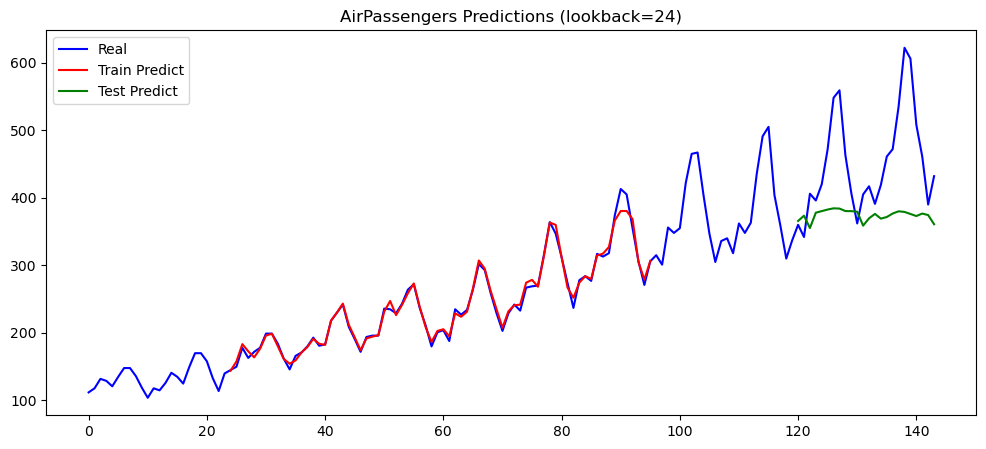

Running lookback=24, hidden_size=100
Epoch 0: lookback 24, train RMSE 248.1488, test RMSE 458.1233
Epoch 100: lookback 24, train RMSE 178.2029, test RMSE 386.0586
Epoch 200: lookback 24, train RMSE 127.4837, test RMSE 331.6086
Epoch 300: lookback 24, train RMSE 90.1096, test RMSE 286.9780
Epoch 400: lookback 24, train RMSE 64.7306, test RMSE 250.5800
Epoch 500: lookback 24, train RMSE 43.3895, test RMSE 210.1472
Epoch 600: lookback 24, train RMSE 32.1082, test RMSE 182.6014
Epoch 700: lookback 24, train RMSE 25.2736, test RMSE 162.5848
Epoch 800: lookback 24, train RMSE 20.9860, test RMSE 146.8721
Epoch 900: lookback 24, train RMSE 19.5770, test RMSE 135.0039
Epoch 1000: lookback 24, train RMSE 13.9672, test RMSE 124.7358
Epoch 1100: lookback 24, train RMSE 12.0138, test RMSE 115.1112
Epoch 1200: lookback 24, train RMSE 9.8877, test RMSE 110.9676
Epoch 1300: lookback 24, train RMSE 9.1355, test RMSE 104.4345
Epoch 1400: lookback 24, train RMSE 7.2811, test RMSE 99.1640
Epoch 1500: look

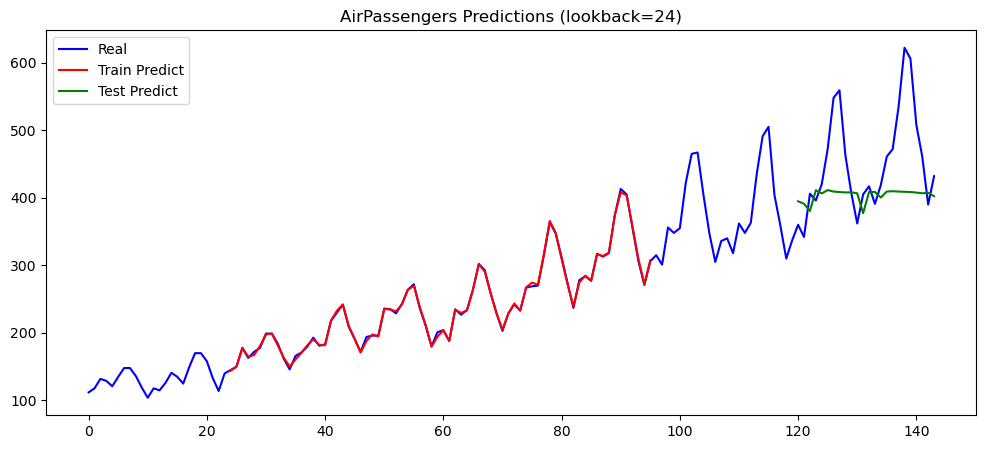

Running lookback=36, hidden_size=50
Epoch 0: lookback 36, train RMSE 261.4082, test RMSE 482.2013
Epoch 100: lookback 36, train RMSE 222.1904, test RMSE 442.3357
Epoch 200: lookback 36, train RMSE 190.8716, test RMSE 410.1986
Epoch 300: lookback 36, train RMSE 162.2991, test RMSE 380.4783
Epoch 400: lookback 36, train RMSE 135.0732, test RMSE 351.5059
Epoch 500: lookback 36, train RMSE 110.9706, test RMSE 324.8031
Epoch 600: lookback 36, train RMSE 90.7997, test RMSE 300.7763
Epoch 700: lookback 36, train RMSE 75.1422, test RMSE 279.4417
Epoch 800: lookback 36, train RMSE 64.9843, test RMSE 261.7134
Epoch 900: lookback 36, train RMSE 54.4120, test RMSE 244.9859
Epoch 1000: lookback 36, train RMSE 45.3169, test RMSE 226.6869
Epoch 1100: lookback 36, train RMSE 39.3542, test RMSE 211.4202
Epoch 1200: lookback 36, train RMSE 35.2526, test RMSE 198.3809
Epoch 1300: lookback 36, train RMSE 31.7396, test RMSE 186.3631
Epoch 1400: lookback 36, train RMSE 28.3698, test RMSE 174.7845
Epoch 1500

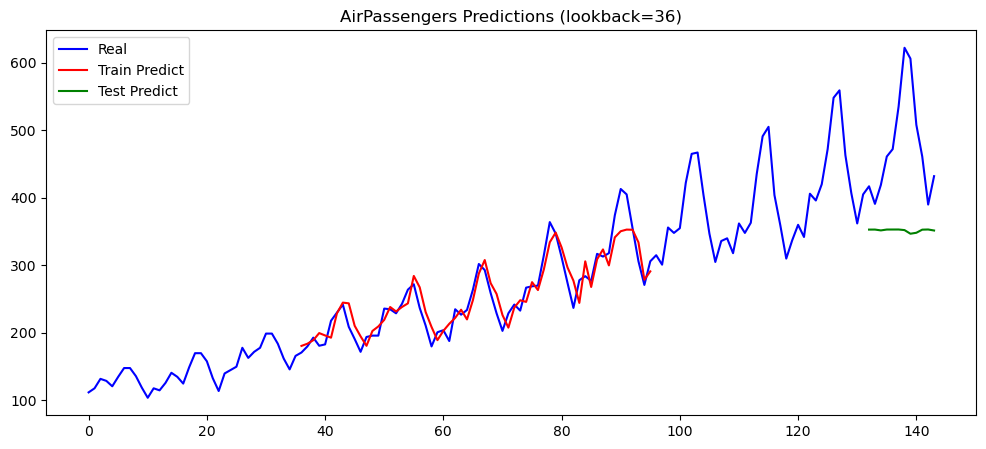

Running lookback=36, hidden_size=100
Epoch 0: lookback 36, train RMSE 261.0619, test RMSE 481.9206
Epoch 100: lookback 36, train RMSE 191.9074, test RMSE 411.2675
Epoch 200: lookback 36, train RMSE 139.5538, test RMSE 356.3381
Epoch 300: lookback 36, train RMSE 99.3235, test RMSE 311.2177
Epoch 400: lookback 36, train RMSE 72.9192, test RMSE 275.9970
Epoch 500: lookback 36, train RMSE 56.1700, test RMSE 248.8312
Epoch 600: lookback 36, train RMSE 44.1393, test RMSE 225.7559
Epoch 700: lookback 36, train RMSE 36.1758, test RMSE 209.8355
Epoch 800: lookback 36, train RMSE 30.4519, test RMSE 195.9917
Epoch 900: lookback 36, train RMSE 25.8574, test RMSE 181.2871
Epoch 1000: lookback 36, train RMSE 21.4456, test RMSE 167.4228
Epoch 1100: lookback 36, train RMSE 17.9962, test RMSE 154.3100
Epoch 1200: lookback 36, train RMSE 16.8360, test RMSE 146.7545
Epoch 1300: lookback 36, train RMSE 17.5886, test RMSE 134.2185
Epoch 1400: lookback 36, train RMSE 16.0928, test RMSE 132.2982
Epoch 1500: 

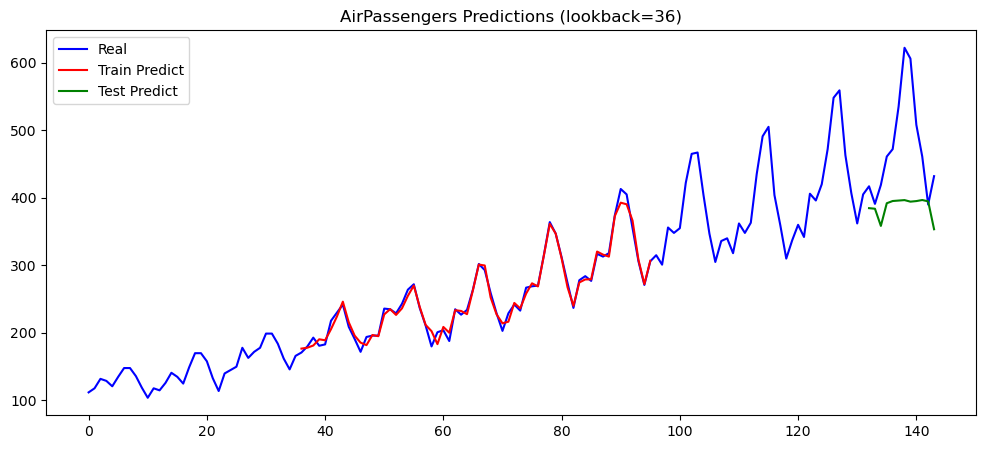

In [17]:
lookbacks = [1, 3, 12, 24, 36]
hidden_sizes = [50, 100]

results = {}

for lb in lookbacks:
    for hs in hidden_sizes:
        print("="*50)
        print(f"Running lookback={lb}, hidden_size={hs}")
        print("="*50)

        model, losses, Xtr, ytr, Xte, yte, tr_size = run_experiment(
            lookback=lb,
            hidden_size=hs,
            num_epochs=2000,
            lr=0.01,
            batch_size=8
        )

        results[(lb, hs)] = (model, losses, Xtr, ytr, Xte, yte, tr_size)

        plot_predicts_model(model, lb, Xtr, Xte, tr_size)


### Final Summary

A series of experiments was conducted to analyze the impact of different lookback window sizes on LSTM-based forecasting of the AirPassengers dataset. The lookback parameter defines how many previous time steps are provided to the model as input for predicting the next value. The tested configurations included window sizes of 1, 3, 12, 24, and 36 months.

The results demonstrate a clear dependency between the lookback size and the model’s learning behavior:

- A **lookback of 1** enables the model to follow the overall upward trend of the passenger volume but does not allow capturing seasonal fluctuations. Test predictions remain overly smooth and fail to reproduce annual peaks.
- With a **lookback of 3**, seasonal variations become more visible in both training and test predictions. However, the ability to generalize future behavior remains limited.
- A **lookback of 12** produces the most balanced and accurate results. One full year of historical data allows the model to incorporate both trend and annual seasonality, leading to significantly improved forecasting quality on previously unseen values.
- Increasing the lookback further to **24** and **36** months results in a closer fit to the training data, but the quality of test predictions declines. The forecast becomes oversmoothed, indicating **overfitting** to the historical sequence. The model increasingly memorizes specific past patterns rather than learning reproducible seasonal structure.

**Conclusion:**
A lookback window of approximately one seasonal cycle (12 months) achieves the best generalization performance for this dataset. This configuration provides the necessary temporal context to model both seasonal and long-term trends, while avoiding excessive overfitting observed with larger input windows. Future improvements may include data scaling, multi-step forecasting architectures, or additional regularization to enhance prediction accuracy on later years where seasonal amplitude sharply increases.
